In [1]:
#Assignment 02, ITC 300
#Hamidullah Rezae

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../Data/death_data.csv")

In [3]:
df.head()

,Unnamed: 0,year,month,intent,police,sex,age,race,hispanic,place,education
0,1,2012,1,Suicide,0,M,34.0,Asian/Pacific Islander,100,Home,BA+
1,2,2012,1,Suicide,0,F,21.0,White,100,Street,Some college
2,3,2012,1,Suicide,0,M,60.0,White,100,Other specified,BA+
3,4,2012,2,Suicide,0,M,64.0,White,100,Home,BA+
4,5,2012,2,Suicide,0,M,31.0,White,100,Other specified,HS/GED


In [4]:
df.isnull().any()

Unnamed: 0    False
year          False
month         False
intent         True
police        False
sex           False
age            True
race          False
hispanic      False
place          True
education      True
dtype: bool

In [5]:
df.dropna(inplace=True)

#We drop all inconsistent values from our dataset.

In [6]:
df.isnull().any()

#There is no inconsistent values in our dataset right now.

Unnamed: 0    False
year          False
month         False
intent        False
police        False
sex           False
age           False
race          False
hispanic      False
place         False
education     False
dtype: bool

In [7]:
df_F= df[(df["intent"]== "Suicide") & (df["sex"]== "F")]
df_female= df_F.year.value_counts()
df_female

#Shows the number of female participants

year
2014    2956
2013    2902
2012    2721
Name: count, dtype: int64

In [8]:
df_M= df[(df["intent"]== "Suicide") & (df["sex"]== "M")]
df_male= df_M.year.value_counts()
df_male

#Shows the number of male participants

year
2014    18083
2013    17990
2012    17639
Name: count, dtype: int64

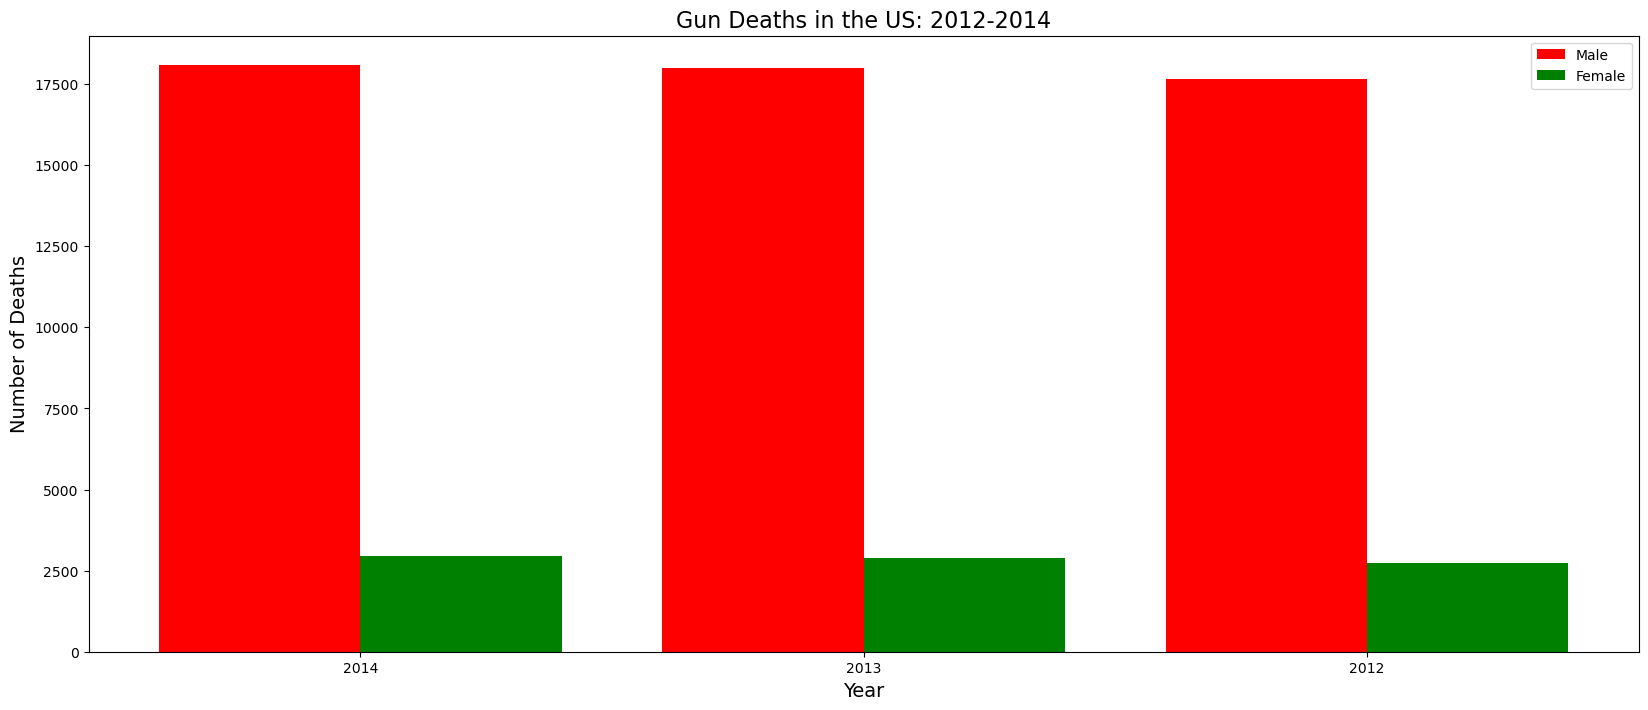

In [9]:
#1- What is the number of annual suicide gun deaths in the United States from 2012 to 2014, by gender?

plt.figure(figsize = (20, 8))
width = 0.4
x =np.arange(len(df_male))
plt.bar(x, df_male, width =width,  color="red")
plt.bar(x+0.4, df_female, width = 0.4,  color="g")
plt.title('Gun Deaths in the US: 2012-2014', fontsize=16)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Number of Deaths",fontsize=14)
plt.xticks(x+width/2, df_male.index)

plt.legend(["Male","Female"])
plt.savefig('chart1_gender.png', bbox_inches='tight', dpi=150)
plt.show()
#Male have higher death rate considered to females and this fact
#has seen little change from 2012 to 2014


In [10]:
#2- What is the number of gun deaths by race in the United States per 100,000 people from 2012 to 2014?


Death_Race= df.race.value_counts(ascending=True)*100/100000
Death_Race

race
Native American/Native Alaskan     0.878
Asian/Pacific Islander             1.261
Hispanic                           8.603
Black                             22.675
White                             64.598
Name: count, dtype: float64

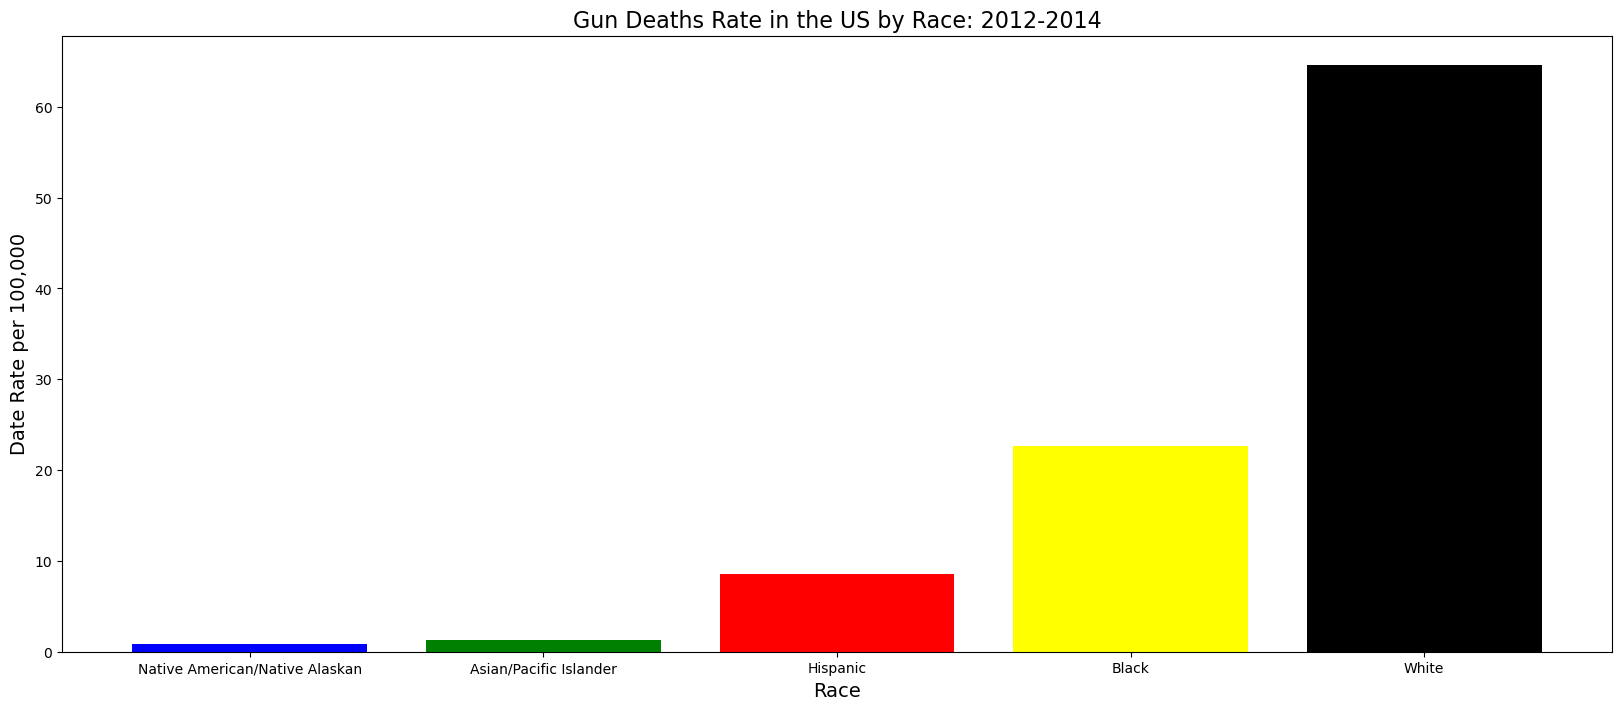

In [11]:
plt.figure(figsize = (20,8))
x = range(len(Death_Race))
plt.bar(x,Death_Race,color=["blue","g","red","yellow","black"],width=0.8)
plt.title("Gun Deaths Rate in the US by Race: 2012-2014", fontsize=16)
plt.xticks(x, Death_Race.index)
plt.xlabel("Race", fontsize=14)
plt.ylabel("Date Rate per 100,000", fontsize=14)
plt.savefig('chart2_race.png', bbox_inches='tight', dpi=150)
plt.show()
#the bar chart demonstrates that the white people (64.5%) are the
#most vulnerable to gun deaths in the US from 2012 to 2014.

In [12]:
#3- What is the annual number of gun deaths in the United States on average from 2012 to 2014, by cause?



Deaths_Cause= df.intent.value_counts(ascending=False)/100
Deaths_Cause



intent
Suicide         622.91
Homicide        333.29
Accidental       15.98
Undetermined      7.97
Name: count, dtype: float64

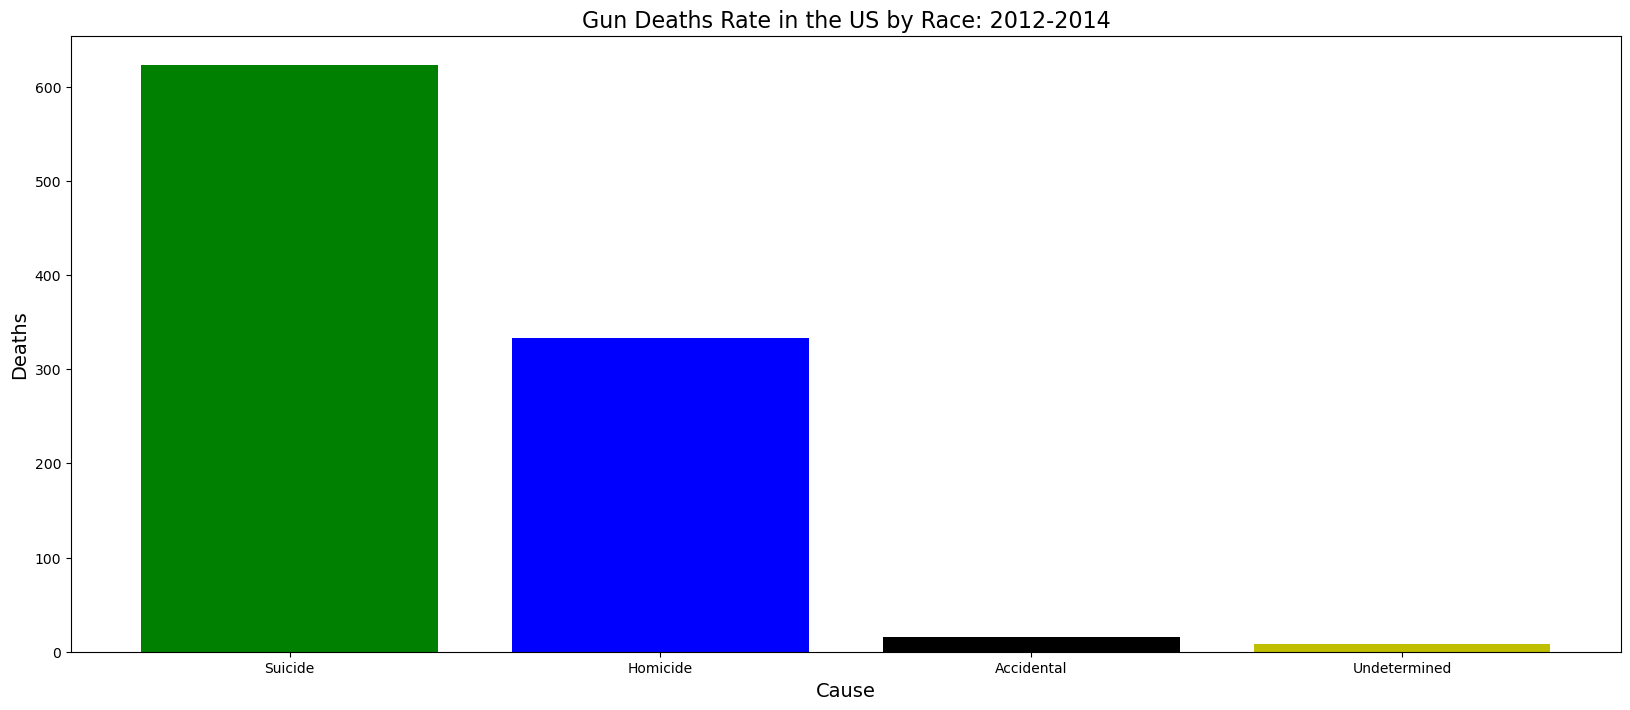

In [13]:
plt.figure(figsize = (20,8))
x =range(len(Deaths_Cause))

plt.bar(x,Deaths_Cause, color=["g","b","k","y"],width=0.8)
plt.title("Gun Deaths Rate in the US by Race: 2012-2014", fontsize=16)
plt.xticks(x,Deaths_Cause.index)
plt.xlabel("Cause", fontsize=14)
plt.ylabel("Deaths",fontsize=14)
plt.savefig('chart3_cause.png', bbox_inches='tight', dpi=150)
plt.show()
#The graph shows that 'suicide' death is the most pervasive
#causes of gun-related deaths in the US

In [14]:
#4- What is the percentage per 100,000 people of annual gun deaths in the United States from 2012 to 2014, by cause?

percentageDeaths_Cause= df.intent.value_counts(ascending=True)*100/100000
percentageDeaths_Cause


intent
Undetermined     0.797
Accidental       1.598
Homicide        33.329
Suicide         62.291
Name: count, dtype: float64

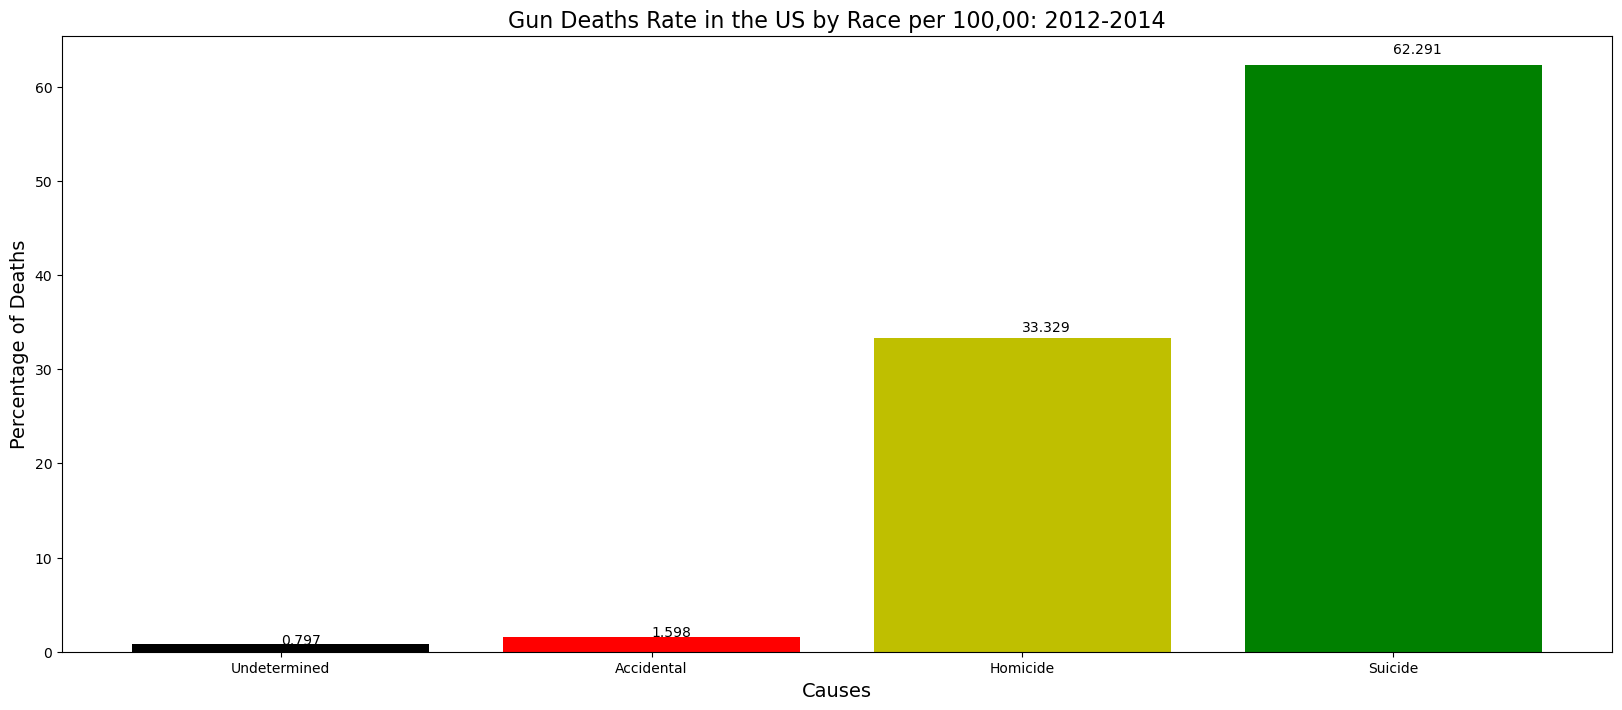

In [15]:
plt.figure(figsize = (20,8))
x = range(len(percentageDeaths_Cause))
ax = plt.axes();
ax.bar(x,percentageDeaths_Cause, color=["k","r","y","g"], width=0.8,label="Percentage")
plt.title("Gun Deaths Rate in the US by Race per 100,00: 2012-2014",fontsize=16)
plt.xticks(x,percentageDeaths_Cause.index)
plt.xlabel("Causes", fontsize=14, )
plt.ylabel("Percentage of Deaths", fontsize=14)

for x in ax.patches:
    W=x.get_width()
    H=x.get_height()
    x,y=x.get_xy()
    
    ax.annotate(H, (x+ W/2, y+ H*1.02))
plt.savefig('chart4_cause_pct.png', bbox_inches='tight', dpi=150)
plt.show()  
#The graph shows that suicide with 62.3% PER 100,000 was the highest cause of gun deaths in the US from 2012-2014

In [16]:
#5- What is the percentage of annual suicide gun deaths in the United States from 2012 to 2014, by year?

Suicide_Year =df[df["intent"] =="Suicide"]
percentage_Suicide_Year= Suicide_Year.year.value_counts(ascending=True)*100/100000
percentage_Suicide_Year


year
2012    20.360
2013    20.892
2014    21.039
Name: count, dtype: float64

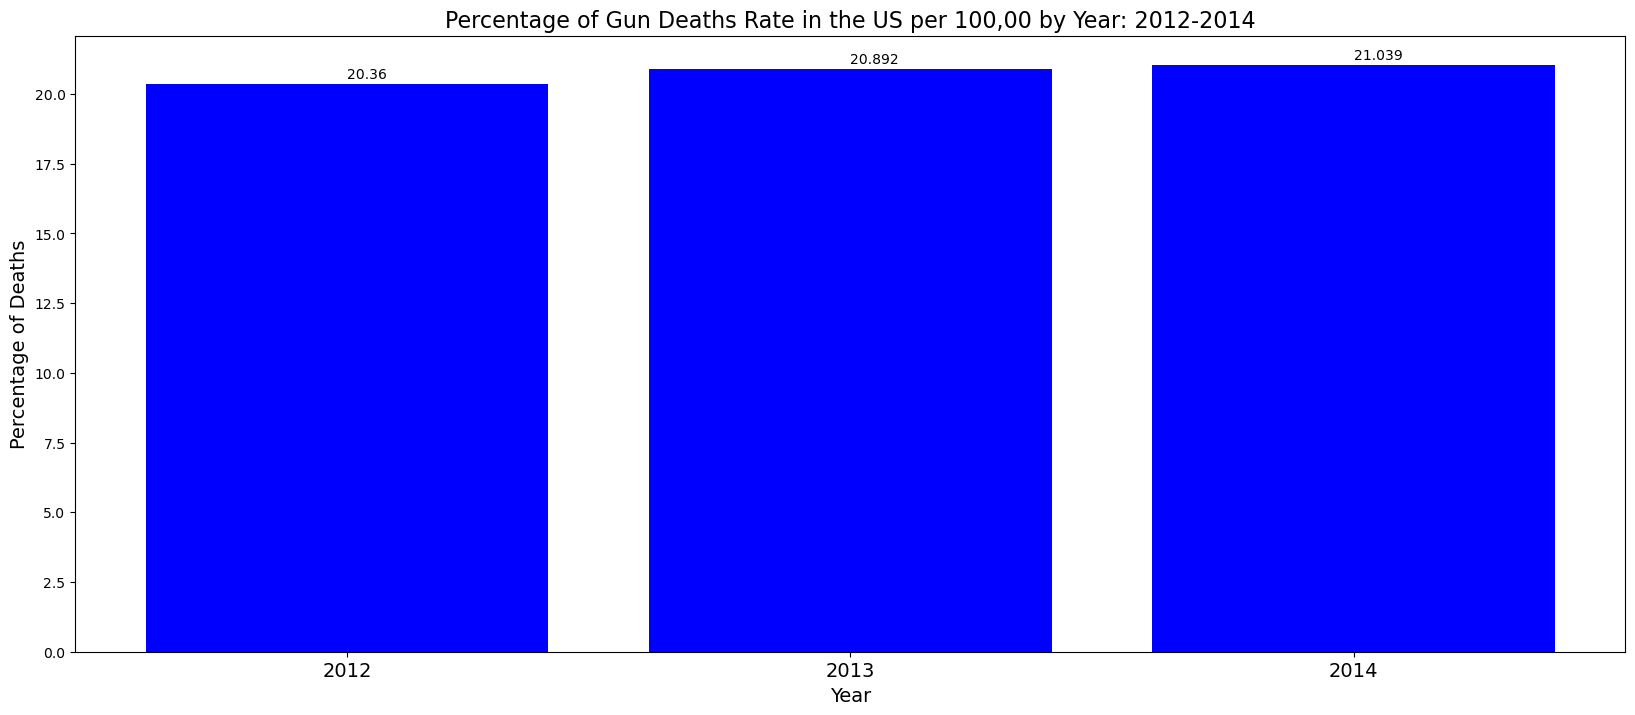

In [17]:
plt.figure(figsize = (20,8))
x=range(len(percentage_Suicide_Year))
ax = plt.axes();

ax.bar(x, percentage_Suicide_Year, color="b", width=0.8)

plt.title("Percentage of Gun Deaths Rate in the US per 100,00 by Year: 2012-2014", fontsize= 16)
plt.ylabel("Percentage of Deaths", fontsize= 14)
plt.xlabel("Year", fontsize= 14)
plt.xticks(x, percentage_Suicide_Year.index, fontsize= 14)
plt.xticks(fontsize= 14)


for x in ax.patches:
    W=x.get_width()
    H=x.get_height()
    x, y =x.get_xy()
    
    ax.annotate(H, (x+ W/2, y+ H*1.01))
plt.savefig('chart5_year.png', bbox_inches='tight', dpi=150)
plt.show()
#The graph depicts the percentage of gun deaths in the US from 2012-2014 per 100,000 and shows the there has
#been substantial change in the these three years

In [18]:
#